In [14]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pickle
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from src.tuning import (
    load_training_data,
    split_data
)

In [7]:
DATA_PATH = project_root / "data" / "preprocessed" / "train_selected.parquet"

print(DATA_PATH)

d:\Projects\credit-card-fraud-detection\data\preprocessed\train_selected.parquet


## Load Dataset

In [10]:
df = load_training_data(DATA_PATH)


Loading training data...
            Shape : (590540, 79)


## Split Data

In [11]:
X_train, X_test, y_train, y_test = split_data(df)


Splitting dataset...
Train : (472432, 78)
Test  : (118108, 78)


## Load Tuned Model

In [12]:
model_path = project_root / "models" / "lightgbm_tuned.pkl"

with open(model_path, "rb") as f:
    model = pickle.load(f)

model

,num_leaves,127
,learning_rate,0.03
,n_estimators,700
,objective,'binary'
,class_weight,'balanced'
,subsample,0.7
,colsample_bytree,0.7
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1


## Predictions

In [13]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

## Evaluation Metrics

In [15]:
roc_auc = roc_auc_score(y_test, y_prob)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("=" * 60)
print("MODEL EVALUATION")
print("=" * 60)

print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

MODEL EVALUATION
ROC-AUC   : 0.9069
Precision : 0.2417
Recall    : 0.7159
F1 Score  : 0.3614

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.92      0.95    113975
           1       0.24      0.72      0.36      4133

    accuracy                           0.91    118108
   macro avg       0.62      0.82      0.66    118108
weighted avg       0.96      0.91      0.93    118108



## Confusion Matrix

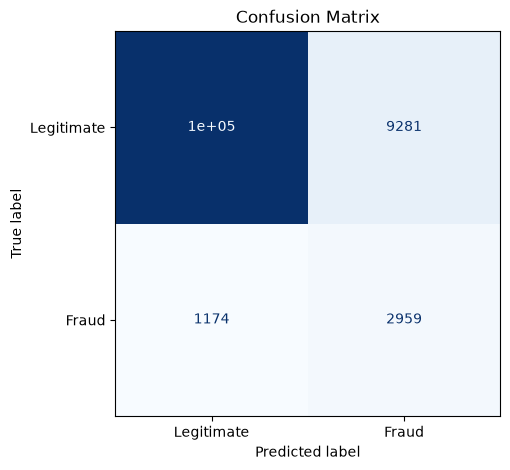

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

fig, ax = plt.subplots(figsize=(6, 5))

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False
)

plt.title("Confusion Matrix")
plt.show()

## ROC Curve

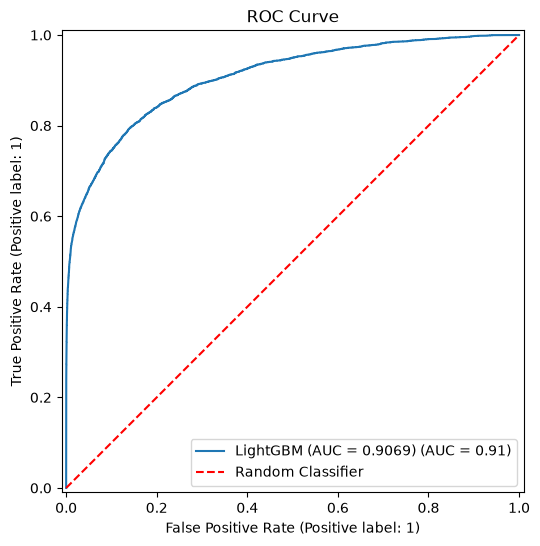

In [17]:
fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax,
    name=f"LightGBM (AUC = {roc_auc:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="red",
    label="Random Classifier"
)

plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve

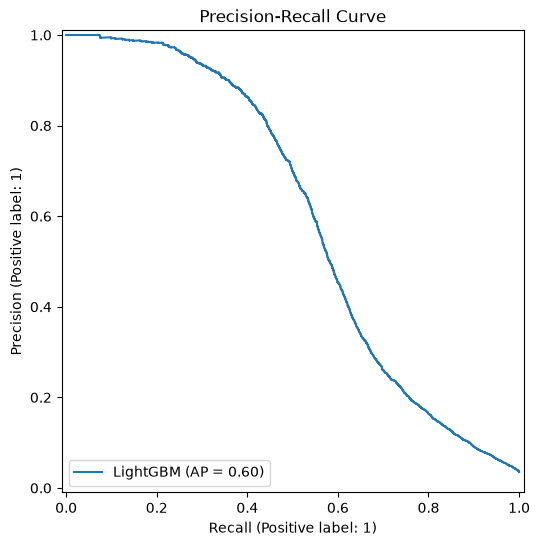

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_prob,
    ax=ax,
    name="LightGBM"
)

plt.title("Precision-Recall Curve")
plt.show()

## Feature Importance

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
2,card1,15946
0,TransactionAmt,13695
6,tx_hour,7222
7,tx_day_of_week,4749
77,id_20,4396
58,id_19,4087
47,R_email_freq,3814
46,DeviceInfo_freq,3415
3,card4,2088
54,id_13,1879


## Plotting Top 20 Features

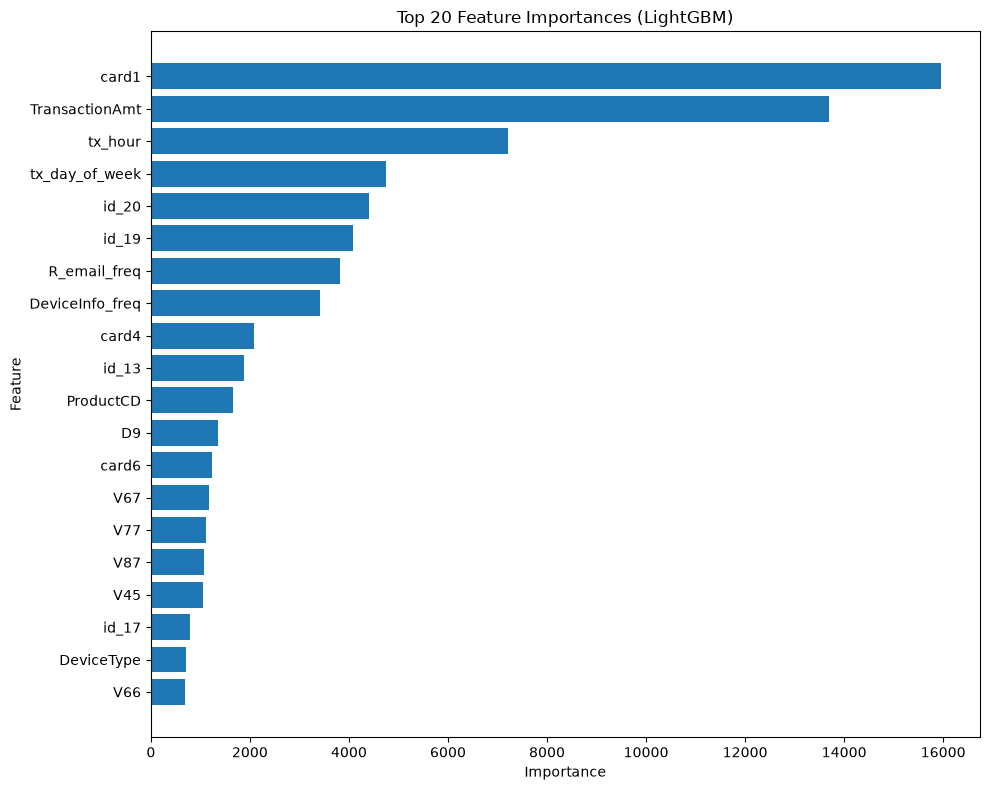

In [20]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()